In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def show_histo(df):
    plt.figure(figsize=(12, 7))
    sns.histplot(data=df, x='generated', kde=True, bins=50)
    plt.title("Prediction Probability Distribution", fontsize=16)
    plt.xlabel("Predicted Probability (Generated = 1)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()
    print(df['generated'].describe())

In [3]:
sub = pd.read_csv("./data/submission_binoculars(82).csv", encoding='utf-8-sig')
sub

,ID,generated
0,TEST_0000,0.925926
1,TEST_0001,1.000000
2,TEST_0002,0.810185
3,TEST_0003,1.000000
4,TEST_0004,0.802469
...,...,...
1957,TEST_1957,1.000000
1958,TEST_1958,0.877976
1959,TEST_1959,0.000000
1960,TEST_1960,0.000000


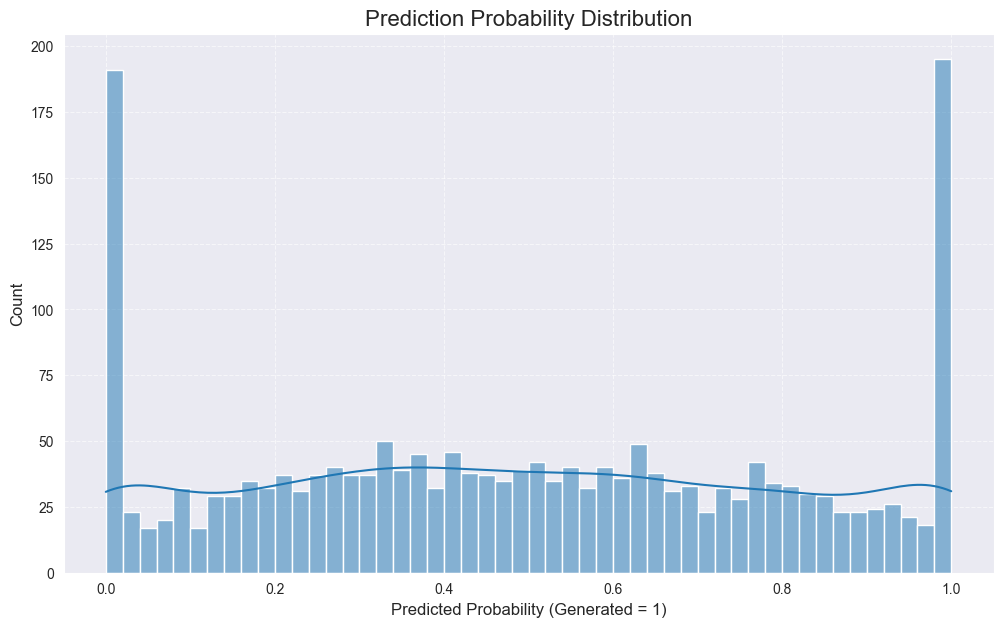

count    1962.000000
mean        0.495071
std         0.316638
min         0.000000
25%         0.238209
50%         0.490196
75%         0.763247
max         1.000000
Name: generated, dtype: float64


In [4]:
show_histo(sub)

In [5]:
total = len(sub)
max_height = total // 2 - 511
total, max_height

(1962, 470)

In [6]:
targets = sub['generated'].tolist()
targets

[0.92592587073644,
 1.0,
 0.8101850748062134,
 1.0,
 0.8024692535400391,
 0.78125,
 0.7675439119338989,
 0.6313130259513855,
 0.7246377567450206,
 0.3472221394379934,
 0.6685324013233185,
 0.2955081562201181,
 0.7978722453117371,
 0.6845238308111827,
 0.5105401078859966,
 0.0,
 0.3787877659002939,
 0.4378018279870351,
 0.6845238308111827,
 0.4796162247657776,
 0.4229322075843811,
 0.1838234563668569,
 0.440140813589096,
 1.0,
 0.3980892399946848,
 0.6015258530775707,
 0.8535879353682201,
 0.6340580681959789,
 0.4442401230335235,
 0.7411067684491476,
 0.0,
 0.3496502836545309,
 1.0,
 0.1865672568480173,
 0.4930024345715841,
 0.3216912349065145,
 0.0,
 0.2997602025667826,
 0.7887517412503561,
 0.9308509528636932,
 0.7755473256111145,
 1.0,
 0.8364898463090261,
 1.0,
 0.6321839988231659,
 0.5385488271713257,
 1.0,
 1.0,
 0.4504504303137461,
 1.0,
 0.0,
 0.8269719779491425,
 0.2109703918298086,
 0.9013002117474874,
 0.0,
 0.626566509405772,
 1.0,
 0.6381382544835409,
 0.2331003546714782,
 

In [7]:
def sort_by_distance_from_half(arr, return_values=False):
    arr = np.array(arr)

    # 0.5에서의 거리 계산
    distances = np.abs(arr - 0.5)

    # 거리가 먼 순으로 정렬 (내림차순)
    # argsort는 기본적으로 오름차순이므로 음수를 취하거나 [::-1]을 사용
    sorted_indices = np.argsort(-distances)

    if return_values:
        sorted_values = arr[sorted_indices]
        return sorted_indices, sorted_values
    else:
        return sorted_indices

In [8]:
center, sorted_values = sort_by_distance_from_half(targets, return_values=True)
center, sorted_values

(array([1902, 1342,  663, ..., 1382,  964,  223], shape=(1962,)),
 array([0.        , 1.        , 1.        , ..., 0.49931134, 0.50064599,
        0.50000002], shape=(1962,)))

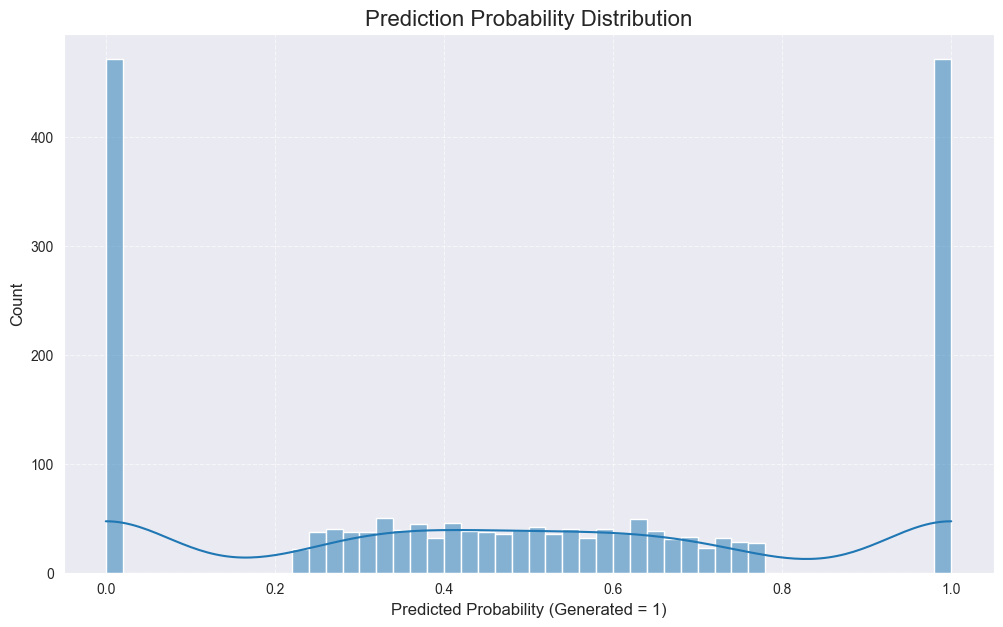

count    1962.000000
mean        0.495075
std         0.363942
min         0.000000
25%         0.238209
50%         0.490196
75%         0.763247
max         1.000000
Name: generated, dtype: float64


In [9]:
new_targets = targets[:]
left, new_center, right = [], [], []
for idx in center:
    data = targets[idx]
    if data < 0.5:
        if len(left) <= max_height:
            left.append(idx)
            new_targets[idx] = 0
        else:
            new_center.append(idx)
    elif data > 0.5:
        if len(right) <= max_height:
            right.append(idx)
            new_targets[idx] = 1
        else:
            new_center.append(idx)

sub['generated'] = new_targets
show_histo(sub)

In [10]:
sub

,ID,generated
0,TEST_0000,1.000000
1,TEST_0001,1.000000
2,TEST_0002,1.000000
3,TEST_0003,1.000000
4,TEST_0004,1.000000
...,...,...
1957,TEST_1957,1.000000
1958,TEST_1958,1.000000
1959,TEST_1959,0.000000
1960,TEST_1960,0.000000


In [11]:
sub.to_csv("./data/submission_binoculars_adjusted.csv", index=False, encoding='utf-8-sig')